In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("ride.csv")

In [3]:
df.shape

(650, 18)

In [4]:
df.isnull().sum()

Ride ID                     0
Request Time                0
Pickup Location             0
latitude                    0
longitude                   0
Dropoff Location            0
Unnamed: 6                  0
Unnamed: 7                  0
Ride Distance (in miles)    0
Fare Amount (in $)          0
Payment Method              0
Driver ID                   0
Vehicle Type                0
Traffic Condition           0
Peak Hours                  0
Day of Week                 0
Public Holiday              0
User Rating                 0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Ride ID                   650 non-null    int64  
 1   Request Time              650 non-null    object 
 2   Pickup Location           650 non-null    object 
 3   latitude                  650 non-null    float64
 4   longitude                 650 non-null    float64
 5   Dropoff Location          650 non-null    object 
 6   Unnamed: 6                650 non-null    float64
 7   Unnamed: 7                650 non-null    float64
 8   Ride Distance (in miles)  650 non-null    float64
 9   Fare Amount (in $)        650 non-null    float64
 10  Payment Method            650 non-null    object 
 11  Driver ID                 650 non-null    object 
 12  Vehicle Type              650 non-null    object 
 13  Traffic Condition         650 non-null    object 
 14  Peak Hours

In [6]:
unnecessary_column = ["Request Time", "Pickup Location", "latitude", "longitude",
                      "Dropoff Location", "Unnamed: 6", "Unnamed: 7", "Driver ID",
                      "Peak Hours"]
df = df.drop(columns = unnecessary_column)

In [7]:
df.head()

,Ride ID,Ride Distance (in miles),Fare Amount (in $),Payment Method,Vehicle Type,Traffic Condition,Day of Week,Public Holiday,User Rating
0,1,5755.572929,595.56,Visa,SUV,High,Thursday,No,1
1,2,7643.323691,784.33,Cash,Sedan,High,Wednesday,Yes,2
2,3,4593.347853,479.33,Debit Card,Motorcycle,Low,Monday,Yes,4
3,4,6833.058843,703.31,PayPal,Sedan,High,Saturday,No,5
4,5,4369.056761,456.91,Debit Card,Bus,Low,Saturday,Yes,2


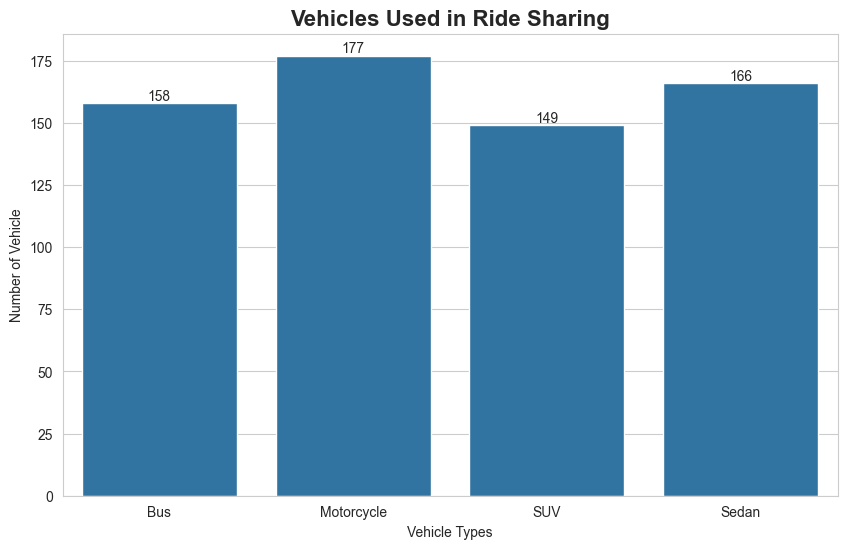

In [8]:
vehicle = df.groupby("Vehicle Type")
total_vehicle = vehicle.size()
plt.figure(figsize = (10, 6))
sns.set_style("whitegrid")
plt.grid(axis="x")
ax = sns.barplot(x = total_vehicle.index, y = total_vehicle.values)
plt.title("Vehicles Used in Ride Sharing", fontsize=16, fontweight="bold")
plt.xlabel("Vehicle Types")
plt.ylabel("Number of Vehicle")
for i in ax.containers:
    ax.bar_label(i)

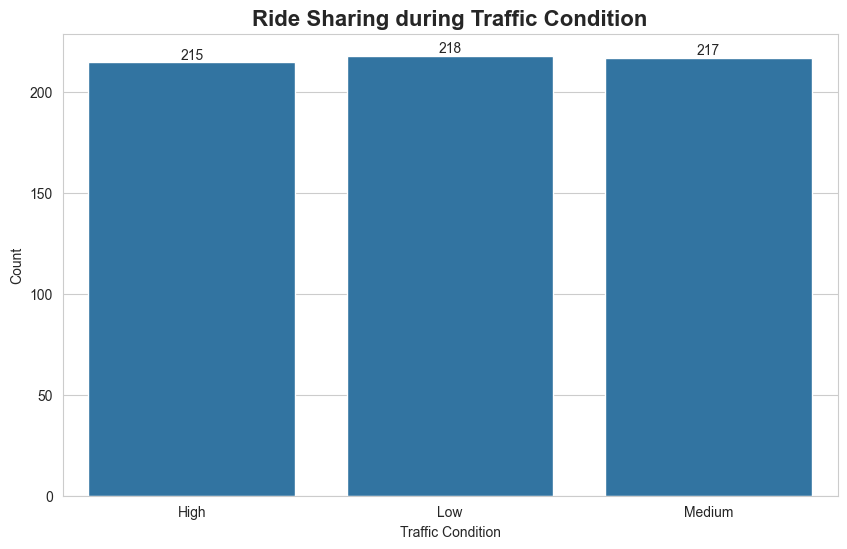

In [93]:
t = df.groupby("Traffic Condition")
total_t = t.size()
plt.figure(figsize = (10,6))
sns.set_style("whitegrid")
plt.grid(axis = "x")
ay = sns.barplot(x = total_t.index, y = total_t.values)
plt.title("Ride Sharing during Traffic Condition", fontsize=16, fontweight="bold")
plt.xlabel("Traffic Condition")
plt.ylabel("Count")
for i in ay.containers:
    ay.bar_label(i)

The data is synthetic so we got the linear relation between ride distance and fare amount.


,Ride Distance (in miles),Fare Amount (in $)
Ride Distance (in miles),1.0,1.0
Fare Amount (in $),1.0,1.0


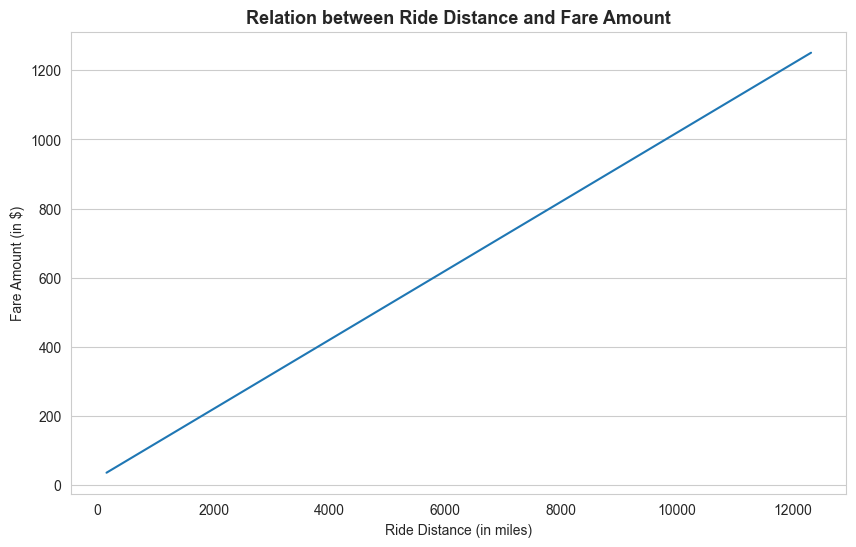

In [90]:
plt.figure(figsize = (10,6))
sns.set_style("whitegrid")
plt.grid(axis = "x")
sns.lineplot(data = df, x = "Ride Distance (in miles)", y = "Fare Amount (in $)")

plt.title("Relation between Ride Distance and Fare Amount", fontsize=13, fontweight="bold")
print("The data is synthetic so we got the linear relation between ride distance and fare amount.")
df[["Ride Distance (in miles)", "Fare Amount (in $)"]].corr()

Day of Week
Friday        94
Monday        81
Saturday      96
Sunday        91
Thursday     105
Tuesday       91
Wednesday     92
dtype: int64

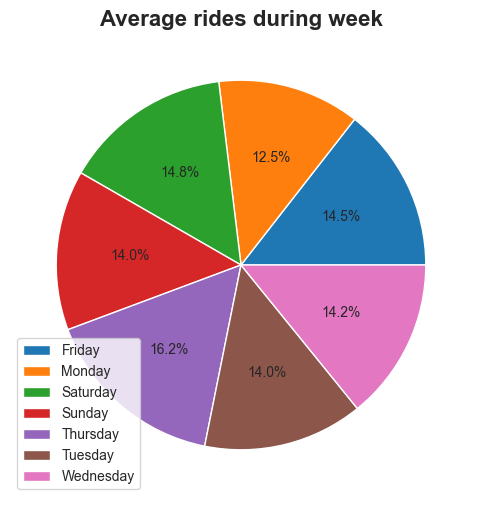

In [105]:
day = df.groupby("Day of Week")
days = day.size()
plt.figure(figsize = (10, 6))
plt.title("Average rides during week", fontsize=16, fontweight="bold")
plt.pie(days.values, autopct = "%1.1f%%", shadow = False)
plt.legend(days.index)
days

The average user rating is  3.0


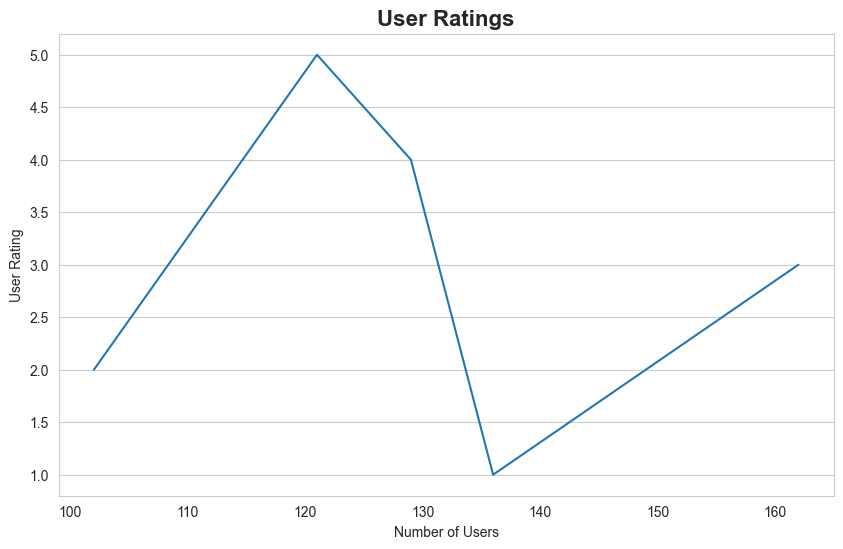

In [85]:
Rating = df.groupby("User Rating").size()
plt.figure(figsize = (10,6))
sns.set_style("whitegrid")
plt.grid(axis = "x")
sns.lineplot(x = Rating.values, y = Rating.index)
plt.title("User Ratings", fontsize = 16, fontweight = "bold")
plt.xlabel("Number of Users")
print("The average user rating is ", df["User Rating"].mean().round(2))

In [86]:
payment = df.groupby("Payment Method")
payment.size()

Payment Method
Apple Pay     119
Cash          136
Debit Card    136
PayPal        118
Visa          141
dtype: int64

Text(0.5, 1.0, 'Payment Methods')

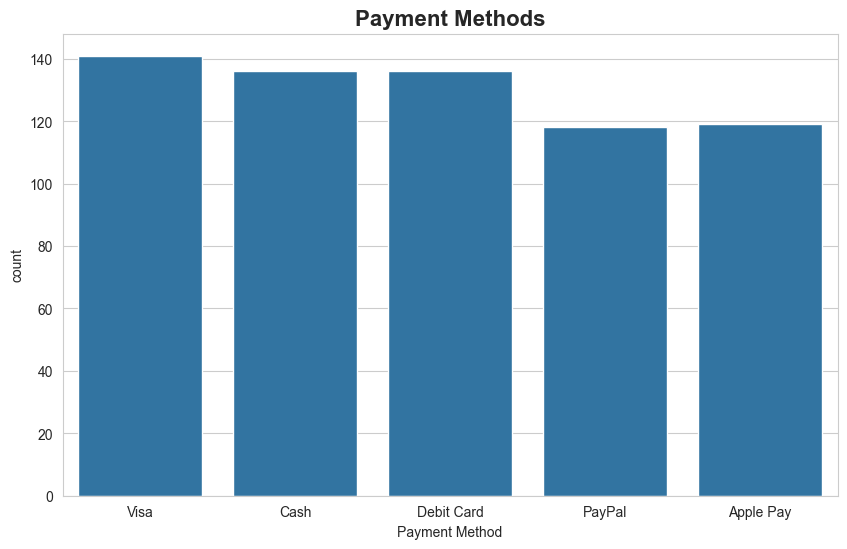

In [97]:
plt.figure(figsize = (10, 6))
sns.countplot(data = df, x = "Payment Method")
plt.title("Payment Methods", fontsize = 16, fontweight = "bold")

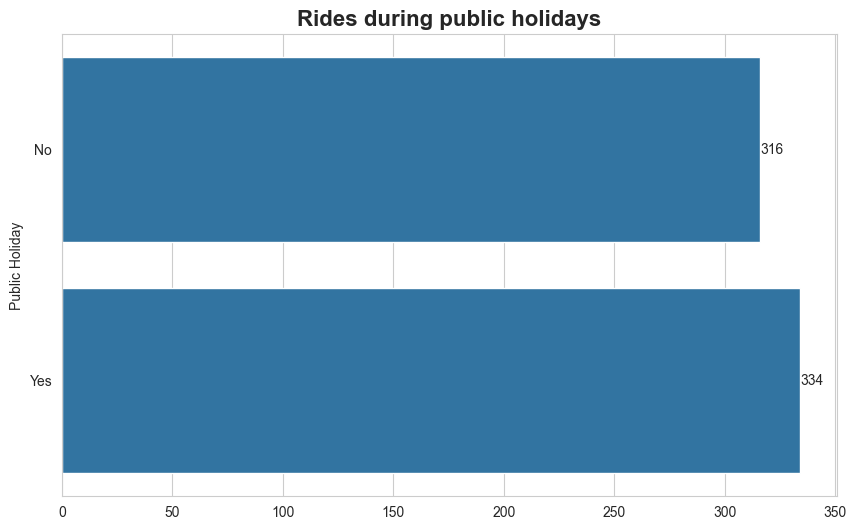

In [109]:
plt.figure(figsize = (10, 6))
holiday = df.groupby("Public Holiday").size()
a = sns.barplot(x = holiday.values, y =holiday.index)
plt.title("Rides during public holidays", fontsize = 16, fontweight = "bold")
for i in a.containers:
    a.bar_label(i)

Text(0, 0.5, 'Average Fare ($)')

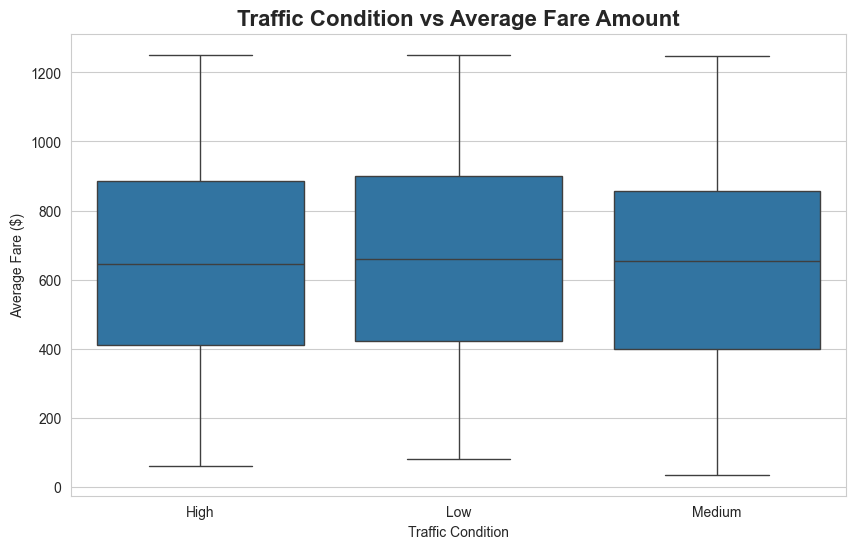

In [116]:
traffic_fare = df.groupby("Traffic Condition")["Fare Amount (in $)"].mean()
plt.figure(figsize=(10, 6))
sns.boxplot(x="Traffic Condition", y="Fare Amount (in $)", data=df)
plt.title("Traffic Condition vs Average Fare Amount", fontsize = 16, fontweight = "bold")
plt.xlabel("Traffic Condition")
plt.ylabel("Average Fare ($)")

In [134]:
max_user = df[df["Fare Amount (in $)"] == df["Fare Amount (in $)"].max()]
max_user


,Ride ID,Ride Distance (in miles),Fare Amount (in $),Payment Method,Vehicle Type,Traffic Condition,Day of Week,Public Holiday,User Rating
297,298,12311.172186,1251.12,Debit Card,Bus,High,Friday,No,2


In [135]:
min_user = df[df["Fare Amount (in $)"] == df["Fare Amount (in $)"].min()]
min_user

,Ride ID,Ride Distance (in miles),Fare Amount (in $),Payment Method,Vehicle Type,Traffic Condition,Day of Week,Public Holiday,User Rating
603,604,152.442233,35.24,PayPal,Sedan,Medium,Sunday,No,1


In [153]:
pay = df.groupby("Payment Method")
cash = df[df["Payment Method"] == "Cash"]
print(pay.size())
print(f"{len(cash)} paid in cash.")
print("People who paid by cash:")
cash

Payment Method
Apple Pay     119
Cash          136
Debit Card    136
PayPal        118
Visa          141
dtype: int64
136 paid in cash.
People who paid by cash:


,Ride ID,Ride Distance (in miles),Fare Amount (in $),Payment Method,Vehicle Type,Traffic Condition,Day of Week,Public Holiday,User Rating
1,2,7643.323691,784.33,Cash,Sedan,High,Wednesday,Yes,2
6,7,8282.631826,848.26,Cash,Motorcycle,Medium,Monday,Yes,3
8,9,8021.228125,822.12,Cash,SUV,Medium,Monday,No,2
15,16,4682.455611,488.25,Cash,Sedan,Medium,Tuesday,No,3
22,23,3533.059276,373.31,Cash,Sedan,Low,Monday,No,5
...,...,...,...,...,...,...,...,...,...
625,626,10722.165066,1092.22,Cash,SUV,Medium,Saturday,Yes,2
632,633,3593.985684,379.40,Cash,Sedan,Low,Thursday,No,5
633,634,3989.588588,418.96,Cash,Bus,High,Tuesday,Yes,3
638,639,10643.084826,1084.31,Cash,SUV,Low,Monday,No,5


In [154]:
total_fare = df["Fare Amount (in $)"].sum()
total_fare

np.float64(422531.84)